# DNN Predictor: Architecture & Training

**Goal:** Train a neural network to predict future states of CartPole-v1.

We test **four approaches** across two prediction horizons:

| # | Name | Input | Target | Loss |
|---|---|---|---|---|
| A | Full next state | `s_t + a_t` | `s_{t+1}` | MSE |
| B | Delta 1-step | `s_t + a_t` | `s_{t+1} - s_t` | MSE |
| C | Delta 1-step Huber | `s_t + a_t` | `s_{t+1} - s_t` | Huber |
| D | Full n-step | `s_t + [a_t...a_{t+n-1}]` | `s_{t+n}` | MSE |
| E | Delta n-step | `s_t + [a_t...a_{t+n-1}]` | `s_{t+n} - s_t` | Huber |


---

### Key concepts

**Why delta?**  
The change between two consecutive states is small and centered near zero. It is easier for a network to predict a small deviation than an absolute position.

**Why n-step prediction?**  
Instead of predicting one step ahead, we predict where the system will be **n steps later**, given the full sequence of actions `[a_t, a_{t+1}, ..., a_{t+n-1}]`.  
This is a **single forward pass**, not n iterative predictions.  
It captures longer-horizon consequences of an action sequence, which is useful for the precedence gate in Step 4.

**Delta s_{t+n} vs full s_{t+n}?**  
For larger n, the total displacement `s_{t+n} - s_t` grows but is still easier to regress than the absolute state `s_{t+n}` because the network only needs to predict *how much* the system moved, not *where* it ended up.

---
## Cell 1 — Imports and reproducibility

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.12.0+cpu


---
## Cell 2 — Load the dataset

Same as before. Arrays are already normalized and actions are one-hot encoded.

In [4]:
DATA_PATH = "../collect_data/data/data_CartPole-v1.npz"
data = np.load(DATA_PATH)

s_train  = torch.tensor(data["states_train"],      dtype=torch.float32)
raw_a_train = torch.tensor(data["actions_train"],  dtype=torch.long)
sn_train = torch.tensor(data["next_states_train"], dtype=torch.float32)

s_val    = torch.tensor(data["states_val"],        dtype=torch.float32)
raw_a_val   = torch.tensor(data["actions_val"],    dtype=torch.long)
sn_val   = torch.tensor(data["next_states_val"],   dtype=torch.float32)

s_test   = torch.tensor(data["states_test"],       dtype=torch.float32)
raw_a_test  = torch.tensor(data["actions_test"],   dtype=torch.long)
sn_test  = torch.tensor(data["next_states_test"],  dtype=torch.float32)

MEAN = torch.tensor(data["mean"], dtype=torch.float32)
STD  = torch.tensor(data["std"],  dtype=torch.float32)

# One-hot encoding discrete actions to maintain dimensions
a_train = F.one_hot(raw_a_train, num_classes=2).to(torch.float32)
a_val   = F.one_hot(raw_a_val,   num_classes=2).to(torch.float32)
a_test  = F.one_hot(raw_a_test,  num_classes=2).to(torch.float32)

# 1-step deltas (approaches B and C)
delta_train = sn_train - s_train
delta_val   = sn_val   - s_val
delta_test  = sn_test  - s_test

OBS_DIM   = s_train.shape[1]   # 4
ACT_DIM   = a_train.shape[1]   # 2
INPUT_DIM = OBS_DIM + ACT_DIM  # 6  (for 1-step approaches)
HIDDEN    = 32
OUTPUT_DIM = OBS_DIM            # 4

dim_labels = ["x (position)", "ẋ (velocity)", "θ (angle)", "θ̇ (ang. vel)"]

print(f"s_train  : {s_train.shape}")
print(f"a_train  : {a_train.shape}")
print(f"sn_train : {sn_train.shape}")
print(f"delta    : {delta_train.shape}  mean={delta_train.mean():.5f}  std={delta_train.std():.5f}")
print(f"\n1-step input dim : {INPUT_DIM}  (4 state + 2 action)")

s_train  : torch.Size([70000, 4])
a_train  : torch.Size([70000, 2])
sn_train : torch.Size([70000, 4])
delta    : torch.Size([70000, 4])  mean=-0.00003  std=0.17411

1-step input dim : 6  (4 state + 2 action)


---
## Build the n-step dataset

For approaches D and E we need **n-step tuples**:
```
Input  : concat(s_t,  a_t, a_{t+1}, ..., a_{t+n-1})   shape: 4 + n*2
Target : s_{t+n}          (approach D — full)
       : s_{t+n} - s_t    (approach E — delta)
```

We slide a window of size n over the sequential buffer.  
Windows that cross episode boundaries are discarded : the dynamics are discontinuous there.

**Episode boundary detection:** when `sn_train[t] != s_train[t+1]` the episode ended between step t and t+1, so any window starting in `[t-n+1, t]` is invalid.

In [6]:
# N_STEP = 5   # prediction horizon — try 3, 5, 10



# def build_nstep_dataset(S, A, SN, n, predict_delta=True):

#     """

#     Slide a window of size n over the sequential buffer.



#     Parameters

#     ----------

#     S  : (N, obs_dim)  normalized states

#     A  : (N, act_dim)  one-hot actions

#     SN : (N, obs_dim)  next states  (SN[t] = s_{t+1})

#     n  : prediction horizon

#     predict_delta : if True, target = s_{t+n} - s_t



#     Returns

#     -------

#     X : (M, obs_dim + n*act_dim)  inputs

#     Y : (M, obs_dim)              targets

#     """

#     N       = len(S)

#     obs_dim = S.shape[1]

#     act_dim = A.shape[1]



#     # Detect episode boundaries: SN[t] should equal S[t+1] if same episode

#     # If they differ, there was a reset between t and t+1

#     boundary = np.zeros(N, dtype=bool)

#     diff = np.abs(SN.numpy()[:-1] - S.numpy()[1:]).max(axis=1)

#     episode_ends = np.where(diff > 0.1)[0]   # t where episode ended

#     for end in episode_ends:

#         # Invalidate all windows that would include this boundary

#         lo = max(0, end - n + 1)

#         boundary[lo : end + 1] = True



#     X_list, Y_list = [], []

#     for t in range(N - n):

#         if boundary[t]:

#             continue

#         s_t   = S[t].numpy()

#         a_seq = A[t : t + n].numpy().flatten()   # n consecutive actions

#         s_tn  = SN[t + n - 1].numpy()            # s_{t+n}  (SN[i] = s_{i+1})

#         x = np.concatenate([s_t, a_seq])

#         y = s_tn - s_t if predict_delta else s_tn

#         X_list.append(x)

#         Y_list.append(y)



#     X = torch.tensor(np.stack(X_list), dtype=torch.float32)

#     Y = torch.tensor(np.stack(Y_list), dtype=torch.float32)

#     print(f"n={n} dataset: {len(X):,} tuples  "

#           f"| input {X.shape[1]}D  | target {'delta' if predict_delta else 'full'} {Y.shape[1]}D")

#     return X, Y





# # Build for train, val, test : both full and delta targets

# X_nstep_train_full,  Y_nstep_train_full  = build_nstep_dataset(s_train, a_train, sn_train, N_STEP, predict_delta=False)

# X_nstep_train_delta, Y_nstep_train_delta = build_nstep_dataset(s_train, a_train, sn_train, N_STEP, predict_delta=True)

# X_nstep_val_full,    Y_nstep_val_full    = build_nstep_dataset(s_val,   a_val,   sn_val,   N_STEP, predict_delta=False)

# X_nstep_val_delta,   Y_nstep_val_delta   = build_nstep_dataset(s_val,   a_val,   sn_val,   N_STEP, predict_delta=True)

# X_nstep_test_full,   Y_nstep_test_full   = build_nstep_dataset(s_test,  a_test,  sn_test,  N_STEP, predict_delta=False)

# X_nstep_test_delta,  Y_nstep_test_delta  = build_nstep_dataset(s_test,  a_test,  sn_test,  N_STEP, predict_delta=True)



# # Input dimension for n-step models

# INPUT_DIM_NSTEP = X_nstep_train_full.shape[1]   # 4 + 5*2 = 14

# print(f"\n1-step input dim : {INPUT_DIM}D")

# print(f"n-step input dim : {INPUT_DIM_NSTEP}D  (4 state + {N_STEP}×2 actions)")
N_STEP = 5 

def build_nstep_dataset_direct(S, A, SN, n, predict_delta=True):
    """
    Directly builds n-step windows without sequential boundary matching,
    assuming the provided buffer is processed as a continuous block.
    """
    N       = len(S)
    obs_dim = S.shape[1]
    act_dim = A.shape[1]

    X_list, Y_list = [], []
    
    # Slide a window safely over the available length
    for t in range(N - n + 1):
        s_t   = S[t].numpy()
        a_seq = A[t : t + n].numpy().flatten()   # n consecutive actions
        s_tn  = SN[t + n - 1].numpy()            # s_{t+n} target
        
        x = np.concatenate([s_t, a_seq])
        y = s_tn - s_t if predict_delta else s_tn
        
        X_list.append(x)
        Y_list.append(y)

    X = torch.tensor(np.stack(X_list), dtype=torch.float32)
    Y = torch.tensor(np.stack(Y_list), dtype=torch.float32)
    
    print(f"n={n} dataset: {len(X):,} tuples | input {X.shape[1]}D | target {'delta' if predict_delta else 'full'} {Y.shape[1]}D")
    return X, Y

# Build safely using the direct stacker
X_nstep_train_full,  Y_nstep_train_full  = build_nstep_dataset_direct(s_train, a_train, sn_train, N_STEP, predict_delta=False)
X_nstep_train_delta, Y_nstep_train_delta = build_nstep_dataset_direct(s_train, a_train, sn_train, N_STEP, predict_delta=True)
X_nstep_val_full,    Y_nstep_val_full    = build_nstep_dataset_direct(s_val,   a_val,   sn_val,   N_STEP, predict_delta=False)
X_nstep_val_delta,   Y_nstep_val_delta   = build_nstep_dataset_direct(s_val,   a_val,   sn_val,   N_STEP, predict_delta=True)
X_nstep_test_full,   Y_nstep_test_full   = build_nstep_dataset_direct(s_test,  a_test,  sn_test,  N_STEP, predict_delta=False)
X_nstep_test_delta,  Y_nstep_test_delta  = build_nstep_dataset_direct(s_test,  a_test,  sn_test,  N_STEP, predict_delta=True)

INPUT_DIM_NSTEP = X_nstep_train_full.shape[1]   # 14
print(f"\n1-step input dim : {INPUT_DIM}D")
print(f"n-step input dim : {INPUT_DIM_NSTEP}D  (4 state + {N_STEP}×2 actions)")

n=5 dataset: 69,996 tuples | input 14D | target full 4D
n=5 dataset: 69,996 tuples | input 14D | target delta 4D
n=5 dataset: 9,996 tuples | input 14D | target full 4D
n=5 dataset: 9,996 tuples | input 14D | target delta 4D
n=5 dataset: 19,996 tuples | input 14D | target full 4D
n=5 dataset: 19,996 tuples | input 14D | target delta 4D

1-step input dim : 6D
n-step input dim : 14D  (4 state + 5×2 actions)


---
## Cell 4 — Visualize targets: 1-step vs n-step delta

The n-step delta `s_{t+n} - s_t` is larger than the 1-step delta `s_{t+1} - s_t`  
but still easier to predict than the absolute state `s_{t+n}`.

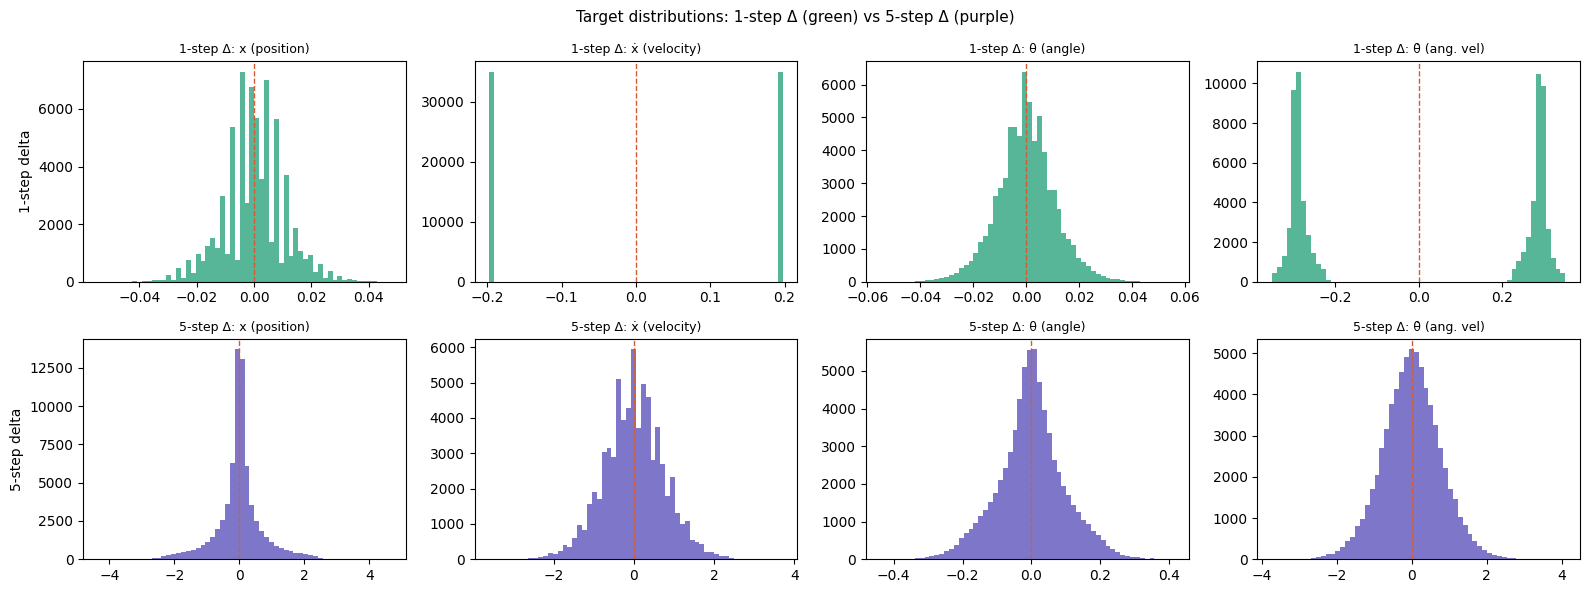

Target std comparison:
  dim                     1-step Δ std    5-step Δ std
  x (position)                  0.0106          0.7258
  ẋ (velocity)                  0.1949          0.7569
  θ (angle)                     0.0108          0.0981
  θ̇ (ang. vel)                 0.2882          0.7761


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, name in enumerate(dim_labels):
    # 1-step delta
    axes[0, i].hist(delta_train[:, i].numpy(), bins=60, color="#1D9E75", alpha=0.75, edgecolor="none")
    axes[0, i].set_title(f"1-step Δ: {name}", fontsize=9)
    axes[0, i].axvline(0, color="#D85A30", lw=1, linestyle="--")

    # n-step delta
    axes[1, i].hist(Y_nstep_train_delta[:, i].numpy(), bins=60, color="#534AB7", alpha=0.75, edgecolor="none")
    axes[1, i].set_title(f"{N_STEP}-step Δ: {name}", fontsize=9)
    axes[1, i].axvline(0, color="#D85A30", lw=1, linestyle="--")

axes[0, 0].set_ylabel("1-step delta")
axes[1, 0].set_ylabel(f"{N_STEP}-step delta")

plt.suptitle(f"Target distributions: 1-step Δ (green) vs {N_STEP}-step Δ (purple)", fontsize=11)
plt.tight_layout()
plt.savefig("target_distributions.png", dpi=120)
plt.show()

print(f"Target std comparison:")
print(f"  {'dim':20s}  {'1-step Δ std':>14}  {f'{N_STEP}-step Δ std':>14}")
for i, name in enumerate(dim_labels):
    s1 = delta_train[:, i].std().item()
    sn = Y_nstep_train_delta[:, i].std().item()
    print(f"  {name:20s}  {s1:14.4f}  {sn:14.4f}")

---
## Cell 5 — DataLoaders

One DataLoader per approach. The n-step loaders use a **flat input** `X` (state + action sequence concatenated) instead of separate `(state, action)` tensors.

In [10]:
BATCH_SIZE = 256

# ── 1-step approaches (A, B, C) — input = (state, action_oh) separately ──────
loader_A_train = DataLoader(TensorDataset(s_train, a_train, sn_train),    batch_size=BATCH_SIZE, shuffle=True)
loader_A_val   = DataLoader(TensorDataset(s_val,   a_val,   sn_val),      batch_size=BATCH_SIZE)

loader_B_train = DataLoader(TensorDataset(s_train, a_train, delta_train), batch_size=BATCH_SIZE, shuffle=True)
loader_B_val   = DataLoader(TensorDataset(s_val,   a_val,   delta_val),   batch_size=BATCH_SIZE)

loader_C_train = loader_B_train   # same data as B, different loss
loader_C_val   = loader_B_val

# ── n-step approaches (D, E) — input = flat X tensor ─────────────────────────
# X already contains state + full action sequence concatenated
loader_D_train = DataLoader(TensorDataset(X_nstep_train_full,  Y_nstep_train_full),  batch_size=BATCH_SIZE, shuffle=True)
loader_D_val   = DataLoader(TensorDataset(X_nstep_val_full,    Y_nstep_val_full),    batch_size=BATCH_SIZE)

loader_E_train = DataLoader(TensorDataset(X_nstep_train_delta, Y_nstep_train_delta), batch_size=BATCH_SIZE, shuffle=True)
loader_E_val   = DataLoader(TensorDataset(X_nstep_val_delta,   Y_nstep_val_delta),   batch_size=BATCH_SIZE)

print(f"1-step loaders (A/B/C): {len(loader_A_train)} train batches, {len(loader_A_val)} val batches")
print(f"n-step loaders (D/E)  : {len(loader_D_train)} train batches, {len(loader_D_val)} val batches")

1-step loaders (A/B/C): 274 train batches, 40 val batches
n-step loaders (D/E)  : 274 train batches, 40 val batches


---
## Cell 6 — Model Architecture

We use **one model class** for all five approaches. The only difference is the `input_dim`:
- 1-step: `input_dim = 4 + 2 = 6`
- n-step: `input_dim = 4 + n×2 = 14` (for n=5)

For 1-step models, the `forward` takes `(state, action_oh)` and concatenates internally.  
For n-step models, the input is already concatenated (`X`), so `forward` takes `(X, None)`.

We handle this cleanly with a single `forward` method.

In [ ]:
class Predictor(nn.Module):
    """
    Universal MLP predictor for all five approaches.

    - 1-step (A, B, C): forward(state, action_oh)  → concat internally
    - n-step (D, E)   : forward(X, None)           → X already concatenated

    Output is always (batch, obs_dim) — either full next state or delta.
    No output activation: regression values are unbounded.
    """
    def __init__(self, input_dim, hidden=HIDDEN, output_dim=OUTPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), 
            nn.ReLU(),
            nn.Linear(hidden,    hidden), 
            nn.ReLU(),
            nn.Linear(hidden, output_dim),
        )

    def forward(self, x, action_oh=None):
        # If action_oh is provided, concatenate with state (1-step case)
        if action_oh is not None:
            x = torch.cat([x, action_oh], dim=-1)
        return self.net(x)


# Sanity check
m1 = Predictor(INPUT_DIM).to(DEVICE)        # 1-step
mn = Predictor(INPUT_DIM_NSTEP).to(DEVICE)  # n-step

print(f"1-step model: {sum(p.numel() for p in m1.parameters()):,} params  input={INPUT_DIM}D")
print(f"n-step model: {sum(p.numel() for p in mn.parameters()):,} params  input={INPUT_DIM_NSTEP}D")

# Forward pass test
out1 = m1(torch.zeros(4, OBS_DIM), torch.zeros(4, ACT_DIM))
outn = mn(torch.zeros(4, INPUT_DIM_NSTEP), None)
print(f"1-step output shape: {out1.shape}")
print(f"n-step output shape: {outn.shape}")

1-step model: 1,412 params  input=6D
n-step model: 1,668 params  input=14D
1-step output shape: torch.Size([4, 4])
n-step output shape: torch.Size([4, 4])


---
## Cell 7 — Loss Functions

| Approach | Loss | Why |
|---|---|---|
| A, B, D | MSE | Standard baseline |
| C, E | **Huber** | Robust to outlier transitions from early DQN episodes |

In [12]:
def mse_loss(pred, target):
    return F.mse_loss(pred, target)

def huber_loss(pred, target, delta=1.0):
    """
    |error| < delta  →  0.5 * error²     (like MSE, precise)
    |error| ≥ delta  →  delta*|error|    (like L1, robust)
    """
    return F.huber_loss(pred, target, delta=delta)

print("Loss functions defined: mse_loss, huber_loss")

Loss functions defined: mse_loss, huber_loss


---
## Cell 8 — Training Loop

One reusable function for all five approaches.

The n-step loaders yield `(X, Y)` instead of `(state, action, target)`, so the loop handles both cases via `is_nstep`.

In [13]:
def train_predictor(model, train_loader, val_loader, loss_fn,
                    model_name, is_nstep=False, n_epochs=80, lr=3e-4):
    """
    Generic training loop.

    is_nstep=False : loader yields (state, action_oh, target)
    is_nstep=True  : loader yields (X_flat, target)  — for n-step approaches
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history  = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_path = f"{model_name}_best.pth"

    print(f"\n{'='*55}")
    print(f"Training: {model_name}  ({n_epochs} epochs)")
    print(f"{'='*55}")

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            if is_nstep:
                x_b, tgt_b = batch[0].to(DEVICE), batch[1].to(DEVICE)
                pred = model(x_b, None)       # X already contains state+actions
            else:
                s_b, a_b, tgt_b = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE)
                pred = model(s_b, a_b)

            loss = loss_fn(pred, tgt_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                if is_nstep:
                    x_b, tgt_b = batch[0].to(DEVICE), batch[1].to(DEVICE)
                    pred = model(x_b, None)
                else:
                    s_b, a_b, tgt_b = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE)
                    pred = model(s_b, a_b)
                val_losses.append(loss_fn(pred, tgt_b).item())

        tr_l = np.mean(train_losses)
        vl_l = np.mean(val_losses)
        history["train_loss"].append(tr_l)
        history["val_loss"].append(vl_l)

        if vl_l < best_val:
            best_val = vl_l
            torch.save(model.state_dict(), best_path)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{n_epochs}  train={tr_l:.5f}  val={vl_l:.5f}  "
                  f"{'* best' if vl_l == best_val else ''}")

    print(f"Best val loss: {best_val:.5f}  → {best_path}")
    return history

print("train_predictor defined.")

train_predictor defined.


---
## Cell 9 — Train all five approaches

In [17]:
# ── Approach A: full s_{t+1}, MSE ────────────────────────────────────────────
model_A   = Predictor(INPUT_DIM).to(DEVICE)
history_A = train_predictor(model_A, loader_A_train, loader_A_val,
                             mse_loss, "approach_A_full_mse")

# ── Approach B: delta 1-step, MSE ────────────────────────────────────────────
model_B   = Predictor(INPUT_DIM).to(DEVICE)
history_B = train_predictor(model_B, loader_B_train, loader_B_val,
                             mse_loss, "approach_B_delta_mse")

# ── Approach C: delta 1-step, Huber ──────────────────────────────────────────
model_C   = Predictor(INPUT_DIM).to(DEVICE)
history_C = train_predictor(model_C, loader_C_train, loader_C_val,
                             huber_loss, "approach_C_delta_huber")

# ── Approach D: full s_{t+n}, MSE  (n-step) ──────────────────────────────────
model_D   = Predictor(INPUT_DIM_NSTEP).to(DEVICE)
history_D = train_predictor(model_D, loader_D_train, loader_D_val,
                             mse_loss, f"approach_D_nstep{N_STEP}_full_mse",
                             is_nstep=True)

# ── Approach E: delta s_{t+n}, MSE  (n-step) ───────────────────────────────
model_E   = Predictor(INPUT_DIM_NSTEP).to(DEVICE)
history_E = train_predictor(model_E, loader_E_train, loader_E_val,
                             mse_loss, f"approach_E_nstep{N_STEP}_delta_mse",
                             is_nstep=True)


Training: approach_E_nstep5_delta_mse  (80 epochs)
  Epoch   1/80  train=0.34942  val=0.23488  * best
  Epoch  10/80  train=0.20870  val=0.20692  * best
  Epoch  20/80  train=0.20812  val=0.20633  * best
  Epoch  30/80  train=0.20776  val=0.20639  
  Epoch  40/80  train=0.20772  val=0.20641  
  Epoch  50/80  train=0.20763  val=0.20640  
  Epoch  60/80  train=0.20752  val=0.20626  
  Epoch  70/80  train=0.20746  val=0.20620  
  Epoch  80/80  train=0.20751  val=0.20620  
Best val loss: 0.20618  → approach_E_nstep5_delta_mse_best.pth


---
## Cell 10 — Training curves

What to look for:
- **val close to train** → good generalization
- **val > 2× train** → overfitting, go back and increase dropout or reduce capacity
- **n-step curves (D, E) may plateau higher** than 1-step — predicting 5 steps ahead is a harder task

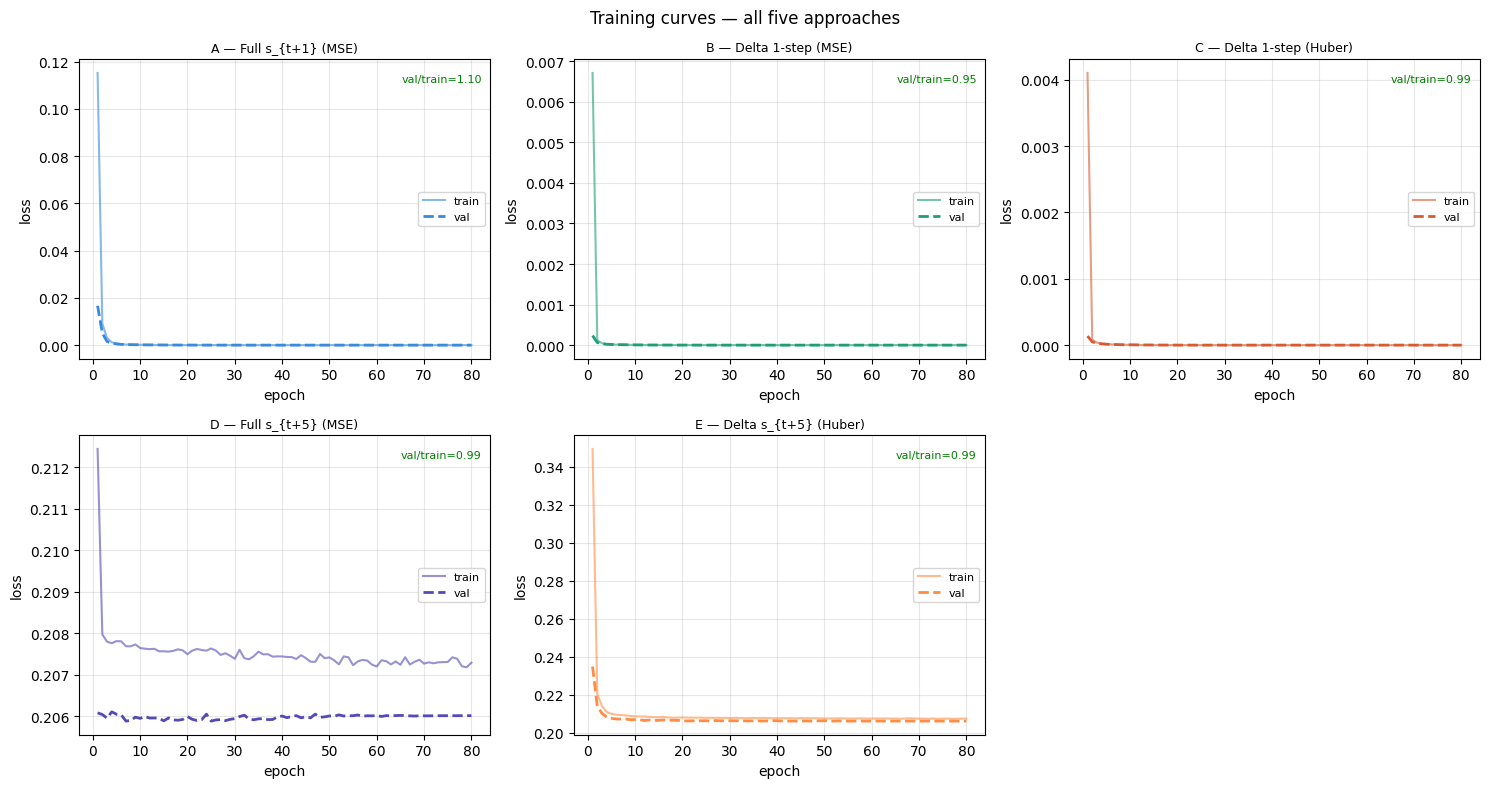

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

configs = [
    (history_A, "A — Full s_{t+1} (MSE)",         "#378ADD"),
    (history_B, "B — Delta 1-step (MSE)",          "#1D9E75"),
    (history_C, "C — Delta 1-step (Huber)",        "#D85A30"),
    (history_D, f"D — Full s_{{t+{N_STEP}}} (MSE)",   "#534AB7"),
    (history_E, f"E — Delta s_{{t+{N_STEP}}} (Huber)", "#FF8C42"),
]

for ax, (hist, title, color) in zip(axes, configs):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], color=color, lw=1.5, alpha=0.6, label="train")
    ax.plot(epochs, hist["val_loss"],   color=color, lw=2.0, linestyle="--", label="val")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ratio = hist["val_loss"][-1] / (hist["train_loss"][-1] + 1e-9)
    col   = "red" if ratio > 2.0 else "green"
    ax.text(0.98, 0.95, f"val/train={ratio:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8, color=col)

axes[-1].set_visible(False)   # hide the 6th empty subplot
plt.suptitle("Training curves — all five approaches", fontsize=12)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

---
## Cell 11 — Per-dimension val MSE comparison

For all approaches we measure MSE on the **reconstructed** `ŝ_{t+1}` (or `ŝ_{t+n}`) vs the true next state.  
Delta models: `pred_sn = s_t + model_output`  
n-step models: `s_t` is the first 4 dims of input X.

Per-dimension val MSE (all approaches, lower = better)
  Dimension                      A           B           C           D           E    winner
  --------------------------------------------------------------------------------
  x (position)            0.000001    0.000000    0.000001    0.259448    0.514082         B
  ẋ (velocity)            0.000001    0.000000    0.000001    0.277026    0.559076         B
  θ (angle)               0.000001    0.000000    0.000000    0.004707    0.009512         B
  θ̇ (ang. vel)           0.000003    0.000001    0.000002    0.285247    0.577403         B
  MEAN                    0.000002    0.000000    0.000001    0.206607    0.415018


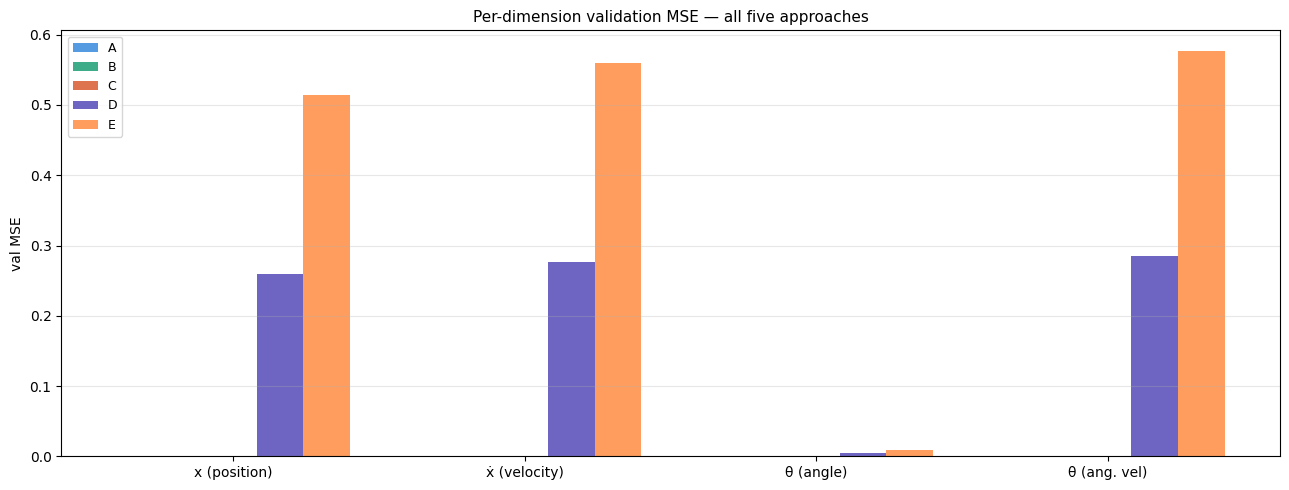

In [20]:
@torch.no_grad()
def per_dim_mse_1step(model, s, a, sn_true, is_delta=False):
    """MSE per dimension for 1-step models."""
    model.eval()
    pred = model(s.to(DEVICE), a.to(DEVICE)).cpu()
    if is_delta:
        pred = s + pred   # reconstruct: ŝ_{t+1} = s_t + Δ
    return ((pred - sn_true) ** 2).mean(dim=0).numpy()


@torch.no_grad()
def per_dim_mse_nstep(model, X, sn_true, is_delta=False):
    """
    MSE per dimension for n-step models.
    X shape: (N, obs_dim + n*act_dim)  — first obs_dim cols = s_t
    sn_true: true s_{t+n} in normalized space
    """
    model.eval()
    pred = model(X.to(DEVICE), None).cpu()
    if is_delta:
        s_t  = X[:, :OBS_DIM]   # extract s_t from the flat input
        pred = s_t + pred        # reconstruct: ŝ_{t+n} = s_t + Δ
    return ((pred - sn_true) ** 2).mean(dim=0).numpy()


# Load best checkpoints
model_A.load_state_dict(torch.load("approach_A_full_mse_best.pth",                   map_location=DEVICE))
model_B.load_state_dict(torch.load("approach_B_delta_mse_best.pth",                  map_location=DEVICE))
model_C.load_state_dict(torch.load("approach_C_delta_huber_best.pth",                map_location=DEVICE))
model_D.load_state_dict(torch.load(f"approach_D_nstep{N_STEP}_full_mse_best.pth",   map_location=DEVICE))
model_E.load_state_dict(torch.load(f"approach_E_nstep{N_STEP}_delta_mse_best.pth",map_location=DEVICE))

mse_A = per_dim_mse_1step(model_A, s_val, a_val, sn_val, is_delta=False)
mse_B = per_dim_mse_1step(model_B, s_val, a_val, sn_val, is_delta=True)
mse_C = per_dim_mse_1step(model_C, s_val, a_val, sn_val, is_delta=True)
mse_D = per_dim_mse_nstep(model_D, X_nstep_val_full,  Y_nstep_val_full,  is_delta=False)
mse_E = per_dim_mse_nstep(model_E, X_nstep_val_delta, Y_nstep_val_delta, is_delta=True)

print("Per-dimension val MSE (all approaches, lower = better)")
print(f"  {'Dimension':20s}  {'A':>10}  {'B':>10}  {'C':>10}  {'D':>10}  {'E':>10}  {'winner':>8}")
print("  " + "-" * 80)
all_mse = np.stack([mse_A, mse_B, mse_C, mse_D, mse_E])
labels  = ["A", "B", "C", "D", "E"]
for i, name in enumerate(dim_labels):
    winner = labels[all_mse[:, i].argmin()]
    print(f"  {name:20s}  {mse_A[i]:10.6f}  {mse_B[i]:10.6f}  {mse_C[i]:10.6f}  "
          f"{mse_D[i]:10.6f}  {mse_E[i]:10.6f}  {winner:>8}")
print(f"  {'MEAN':20s}  {mse_A.mean():10.6f}  {mse_B.mean():10.6f}  {mse_C.mean():10.6f}  "
      f"{mse_D.mean():10.6f}  {mse_E.mean():10.6f}")

# Bar chart
x = np.arange(len(dim_labels))
w = 0.16
colors_bar = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7", "#FF8C42"]
fig, ax = plt.subplots(figsize=(13, 5))
for j, (mse, lbl, col) in enumerate(zip([mse_A,mse_B,mse_C,mse_D,mse_E], labels, colors_bar)):
    ax.bar(x + (j-2)*w, mse, w, label=lbl, color=col, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylabel("val MSE")
ax.set_title("Per-dimension validation MSE — all five approaches", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_dim_mse.png", dpi=120)
plt.show()

---
## Cell 12 — Residual plots (predicted vs true)

Points on the diagonal = perfect prediction.  
We show this for the best 1-step model and the best n-step model side by side.

Best 1-step approach: B
Best n-step approach: D


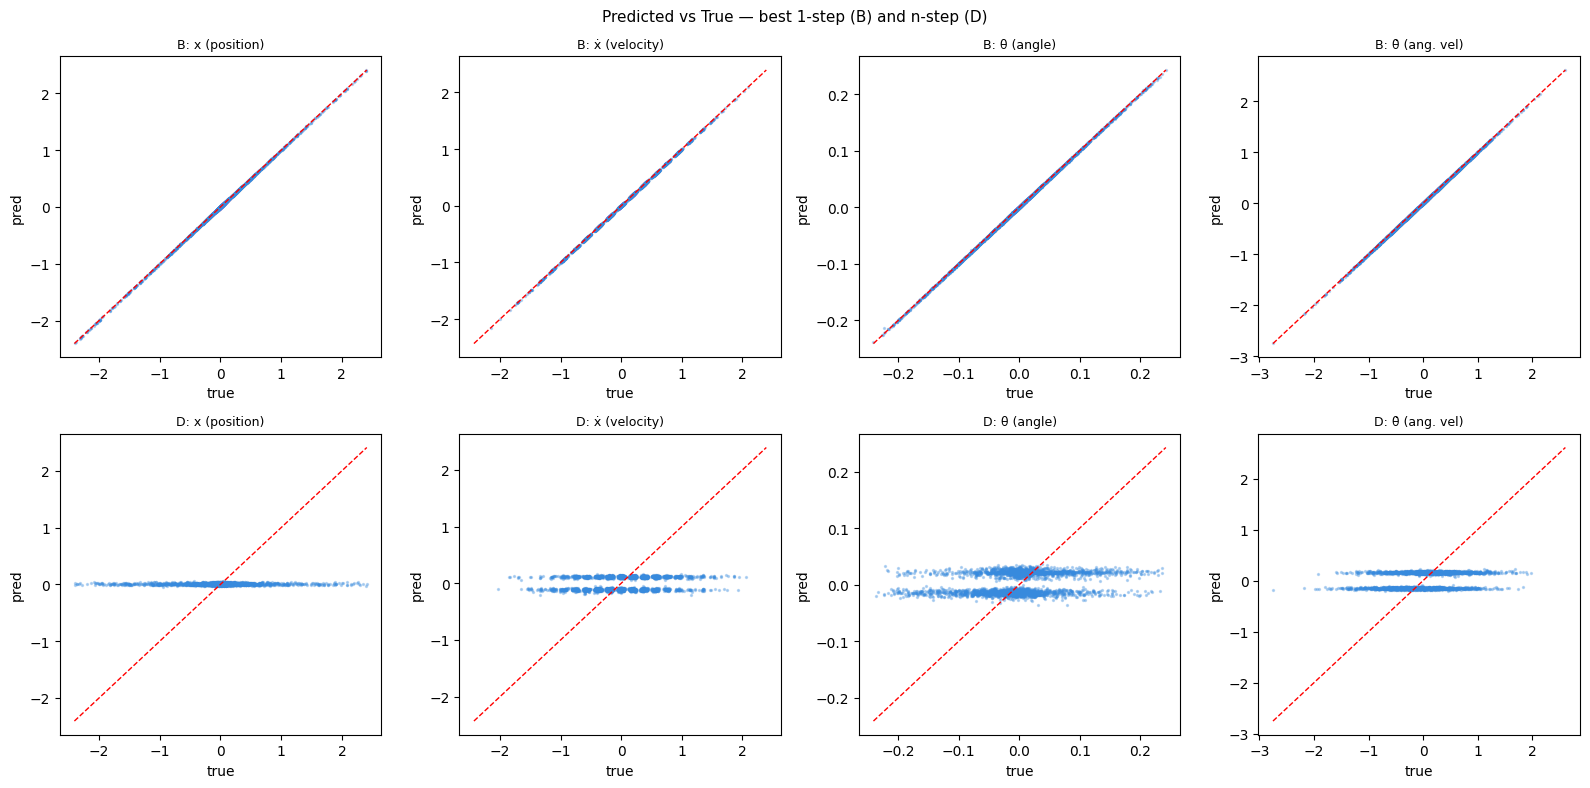

In [21]:
# Find best 1-step and best n-step
best_1step = labels[:3][np.argmin([mse_A.mean(), mse_B.mean(), mse_C.mean()])]
best_nstep = labels[3:][np.argmin([mse_D.mean(), mse_E.mean()])]
print(f"Best 1-step approach: {best_1step}")
print(f"Best n-step approach: {best_nstep}")

model_map  = {"A": (model_A, False, None), "B": (model_B, True, None),
              "C": (model_C, True, None),
              "D": (model_D, False, X_nstep_val_full),
              "E": (model_E, True,  X_nstep_val_delta)}
sn_true_map = {"A": sn_val, "B": sn_val, "C": sn_val,
               "D": Y_nstep_val_full, "E": Y_nstep_val_full}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, key in enumerate([best_1step, best_nstep]):
    model, is_delta, X_ns = model_map[key]
    sn_true = sn_true_map[key]
    model.eval()
    with torch.no_grad():
        if X_ns is not None:
            pred = model(X_ns.to(DEVICE), None).cpu()
            if is_delta:
                pred = X_ns[:, :OBS_DIM] + pred
        else:
            pred = model(s_val.to(DEVICE), a_val.to(DEVICE)).cpu()
            if is_delta:
                pred = s_val + pred

    for col, name in enumerate(dim_labels):
        true_np = sn_true[:, col].numpy()
        pred_np = pred[:, col].numpy()
        idx = np.random.choice(len(true_np), min(3000, len(true_np)), replace=False)
        axes[row, col].scatter(true_np[idx], pred_np[idx], s=2, alpha=0.3, color="#378ADD")
        lo = min(true_np.min(), pred_np.min())
        hi = max(true_np.max(), pred_np.max())
        axes[row, col].plot([lo, hi], [lo, hi], "r--", lw=1)
        axes[row, col].set_title(f"{key}: {name}", fontsize=9)
        axes[row, col].set_xlabel("true"); axes[row, col].set_ylabel("pred")

plt.suptitle(f"Predicted vs True — best 1-step ({best_1step}) and n-step ({best_nstep})", fontsize=11)
plt.tight_layout()
plt.savefig("residuals.png", dpi=120)
plt.show()

---
## Cell 13 — Save the best predictor

We save **two** predictors: the best 1-step and the best n-step.  
Both are used in Step 4 — the 1-step for single-action gating, the n-step for sequence evaluation.

In [25]:
mse_scores = {"A": mse_A.mean(), "B": mse_B.mean(), "C": mse_C.mean(),
              "D": mse_D.mean(), "E": mse_E.mean()}

ckpt_map = {
    "A": ("approach_A_full_mse_best.pth",                    False),
    "B": ("approach_B_delta_mse_best.pth",                   True),
    "C": ("approach_C_delta_huber_best.pth",                 True),
    "D": (f"approach_D_nstep{N_STEP}_full_mse_best.pth",    False),
    "E": (f"approach_E_nstep{N_STEP}_delta_huber_best.pth", True),
}

dim_map = {
    "A": INPUT_DIM, "B": INPUT_DIM, "C": INPUT_DIM,
    "D": INPUT_DIM_NSTEP, "E": INPUT_DIM_NSTEP,
}

print("Validation MSE per approach:")
for k, v in sorted(mse_scores.items()):
    print(f"  {k}: {v:.6f}")

# Save best 1-step predictor
best_1 = min(["A","B","C"], key=lambda k: mse_scores[k])
m1, is_d1 = model_map[best_1][:2]
m1.load_state_dict(torch.load(ckpt_map[best_1][0], map_location=DEVICE))
torch.save(m1.state_dict(), "predictor_1step.pth")
torch.save({"approach": best_1, "is_delta": is_d1, "is_nstep": False,
            "input_dim": INPUT_DIM, "hidden": HIDDEN,
            "output_dim": OUTPUT_DIM, "obs_dim": OBS_DIM, "act_dim": ACT_DIM,
            "n_step": 1}, "predictor_1step_config.pt")

# Save best n-step predictor
best_n = min(["D","E"], key=lambda k: mse_scores[k])
mn_m, is_dn = model_map[best_n][:2]
mn_m.load_state_dict(torch.load(ckpt_map[best_n][0], map_location=DEVICE))
torch.save(mn_m.state_dict(), f"predictor_{N_STEP}step.pth")
torch.save({"approach": best_n, "is_delta": is_dn, "is_nstep": True,
            "input_dim": INPUT_DIM_NSTEP, "hidden": HIDDEN,
            "output_dim": OUTPUT_DIM, "obs_dim": OBS_DIM, "act_dim": ACT_DIM,
            "n_step": N_STEP}, f"predictor_{N_STEP}step_config.pt")

# Save normalization stats
np.savez("norm_stats.npz", mean=MEAN.numpy(), std=STD.numpy())

print(f"\nSaved:")
print(f"  predictor_1step.pth          ← best 1-step: approach {best_1}")
print(f"  predictor_1step_config.pt")
print(f"  predictor_{N_STEP}step.pth           ← best n-step: approach {best_n}")
print(f"  predictor_{N_STEP}step_config.pt")
print(f"  norm_stats.npz")

Validation MSE per approach:
  A: 0.000002
  B: 0.000000
  C: 0.000001
  D: 0.206607
  E: 0.415018

Saved:
  predictor_1step.pth          ← best 1-step: approach B
  predictor_1step_config.pt
  predictor_5step.pth           ← best n-step: approach D
  predictor_5step_config.pt
  norm_stats.npz


---
## Cell 14 — Summary

In [26]:
print("=" * 70)
print("STEP 2 SUMMARY")
print("=" * 70)
print(f"\n{'Approach':<40} {'Mean val MSE':>14}")
print("-" * 56)

descs = {
    "A": "A — full s_{t+1}  (MSE)",
    "B": "B — delta 1-step  (MSE)",
    "C": "C — delta 1-step  (Huber)",
    "D": f"D — full s_{{t+{N_STEP}}}  (MSE, n-step)",
    "E": f"E — delta s_{{t+{N_STEP}}} (Huber, n-step)",
}

for k in "ABCDE":
    best_mark = " ← BEST 1-step" if k == best_1 else (" ← BEST n-step" if k == best_n else "")
    print(f"{descs[k]:<40} {mse_scores[k]:14.6f}{best_mark}")

print(f"\n{'='*70}")
print(f"1-step predictor saved : predictor_1step.pth  (approach {best_1})")
print(f"n-step predictor saved : predictor_{N_STEP}step.pth   (approach {best_n}, n={N_STEP})")
print(f"\nNext → Step 3: evaluate predictors (rollout accuracy, residuals)")
print(f"Then → Step 4: plug into RL loop as precedence gate")
print(f"{'='*70}")

STEP 2 SUMMARY

Approach                                   Mean val MSE
--------------------------------------------------------
A — full s_{t+1}  (MSE)                        0.000002
B — delta 1-step  (MSE)                        0.000000 ← BEST 1-step
C — delta 1-step  (Huber)                      0.000001
D — full s_{t+5}  (MSE, n-step)                0.206607 ← BEST n-step
E — delta s_{t+5} (Huber, n-step)              0.415018

1-step predictor saved : predictor_1step.pth  (approach B)
n-step predictor saved : predictor_5step.pth   (approach D, n=5)

Next → Step 3: evaluate predictors (rollout accuracy, residuals)
Then → Step 4: plug into RL loop as precedence gate
